In [2]:
!pip install -q wfdb pandas numpy matplotlib torch scikit-learn

import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from google.colab import drive

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/ptb-xl-dataset/ptb-xl/'
SAVE_PATH = '/content/drive/MyDrive/ptb-xl-dataset/'

# Regenerate missing X_train_norm
X_train = np.load(SAVE_PATH + 'X_train.npy')
X_test  = np.load(SAVE_PATH + 'X_test.npy')

train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)
train_std[train_std == 0] = 1

X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

np.save(SAVE_PATH + 'X_train_norm.npy', X_train_norm)

# Load labels
y_train_enc = np.load(SAVE_PATH + 'y_train_enc.npy')
y_test_enc  = np.load(SAVE_PATH + 'y_test_enc.npy')

print(f"X_train_norm: {X_train_norm.shape}")
print(f"X_test_norm:  {X_test_norm.shape}")
print(f"y_train_enc:  {y_train_enc.shape}")
print(f"GPU: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 116.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
Mounted at /cont

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class ECGDataset(Dataset):
    """
    PyTorch Dataset for ECG signals.
    Returns masked and original signal pairs for self-supervised pretraining.
    """
    def __init__(self, signals, labels=None, masking_ratio=0.4, ssl=True):
        self.signals       = torch.FloatTensor(signals)  # (N, 1000, 12)
        self.labels        = torch.FloatTensor(labels) if labels is not None else None
        self.masking_ratio = masking_ratio
        self.ssl           = ssl  # if True, return masked signal for SSL pretraining

    def __len__(self):
        return len(self.signals)

    def __mask__(self, signal):
        # Randomly mask 40% of time steps across all leads
        masked    = signal.clone()
        seq_len   = signal.shape[0]
        n_masked  = int(seq_len * self.masking_ratio)
        mask_idx  = torch.randperm(seq_len)[:n_masked]
        masked[mask_idx, :] = 0  # replace masked positions with 0
        return masked, mask_idx

    def __getitem__(self, idx):
        signal = self.signals[idx]  # (1000, 12)
        if self.ssl:
            masked_signal, mask_idx = self.__mask__(signal)
            return masked_signal, signal  # input=masked, target=original
        else:
            return signal, self.labels[idx]

# Create datasets
ssl_dataset   = ECGDataset(X_train_norm, ssl=True)
train_dataset = ECGDataset(X_train_norm, labels=y_train_enc, ssl=False)
test_dataset  = ECGDataset(X_test_norm,  labels=y_test_enc,  ssl=False)

# Create dataloaders
ssl_loader   = DataLoader(ssl_dataset,   batch_size=64, shuffle=True,  num_workers=2)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

print(f"SSL batches:   {len(ssl_loader)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

SSL batches:   307
Train batches: 307
Test batches:  35


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """
    Basic 1D residual block — processes ECG time series data.
    Skip connection allows gradients to flow through deep networks without vanishing.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7,
                               stride=stride, padding=3, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7,
                               padding=3, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)

        # Skip connection — adjusts dimensions if needed
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.skip(x)  # residual connection
        return F.relu(out)


class ECGEncoder(nn.Module):
    """
    1D ResNet encoder for 12-lead ECG signals.
    Input:  (batch, 12, 1000) — 12 leads, 1000 time steps
    Output: (batch, 256)      — learned representation vector
    """
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.embedding_dim = embedding_dim

        # Initial convolution
        self.conv1 = nn.Conv1d(12, 64, kernel_size=15, stride=2, padding=7, bias=False)
        self.bn1   = nn.BatchNorm1d(64)

        # Residual blocks
        self.layer1 = ResidualBlock(64,  64)
        self.layer2 = ResidualBlock(64,  128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4 = ResidualBlock(256, 512, stride=2)

        # Global average pooling + projection
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.project = nn.Linear(512, embedding_dim)

    def forward(self, x):
        # x: (batch, 1000, 12) → transpose to (batch, 12, 1000)
        x = x.transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).squeeze(-1)  # (batch, 512)
        x = self.project(x)           # (batch, 256)
        return x


# Initialise encoder and move to GPU
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = ECGEncoder(embedding_dim=256).to(device)

# Count parameters
total_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder initialised — {total_params:,} trainable parameters")
print(f"Device: {device}")

Encoder initialised — 3,990,656 trainable parameters
Device: cuda


In [8]:
CKPT_PATH = '/content/drive/MyDrive/ptb-xl-dataset/'

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Contrastive Dataset ──────────────────────────────────────────────────────
class ECGContrastiveDataset(Dataset):
    """
    Returns two differently augmented views of the same ECG.
    The encoder is trained to produce similar embeddings for both views.
    """
    def __init__(self, signals):
        self.signals = torch.FloatTensor(signals)

    def __len__(self):
        return len(self.signals)

    def augment(self, signal):
        augmented = signal.clone()

        # Augmentation 1 — random amplitude scaling
        scale = 0.8 + torch.rand(1) * 0.4  # scale between 0.8 and 1.2
        augmented = augmented * scale

        # Augmentation 2 — random time shift
        shift = torch.randint(-50, 50, (1,)).item()
        augmented = torch.roll(augmented, shift, dims=0)

        # Augmentation 3 — random Gaussian noise
        augmented = augmented + torch.randn_like(augmented) * 0.05

        return augmented

    def __getitem__(self, idx):
        signal = self.signals[idx]
        view1  = self.augment(signal)
        view2  = self.augment(signal)
        return view1, view2


# ── NT-Xent Contrastive Loss (SimCLR) ────────────────────────────────────────
class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss.
    Pulls together embeddings of the same ECG, pushes apart different ECGs.
    """
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z1, z2):
        batch_size = z1.shape[0]

        # Normalise embeddings
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)

        # Concatenate and compute similarity matrix
        z  = torch.cat([z1, z2], dim=0)  # (2N, dim)
        sim = torch.mm(z, z.T) / self.temperature  # (2N, 2N)

        # Mask out self-similarities
        mask = torch.eye(2 * batch_size, device=z.device).bool()
        sim.masked_fill_(mask, float('-inf'))

        # Positive pairs are at index i and i+N
        labels = torch.cat([
            torch.arange(batch_size, 2 * batch_size),
            torch.arange(0, batch_size)
        ]).to(z.device)

        loss = F.cross_entropy(sim, labels)
        return loss


# ── Projection Head ──────────────────────────────────────────────────────────
class ProjectionHead(nn.Module):
    """
    Small MLP on top of encoder for contrastive learning.
    Discarded after pretraining — only encoder is kept.
    """
    def __init__(self, embedding_dim=256, projection_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

    def forward(self, x):
        return self.net(x)


# ── Reinitialise everything ───────────────────────────────────────────────────
encoder         = ECGEncoder(embedding_dim=256).to(device)
projection_head = ProjectionHead(256, 128).to(device)
criterion       = NTXentLoss(temperature=0.5)
optimizer       = optim.Adam(
    list(encoder.parameters()) + list(projection_head.parameters()),
    lr=3e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Contrastive dataloader
ssl_dataset = ECGContrastiveDataset(X_train_norm)
ssl_loader  = DataLoader(ssl_dataset, batch_size=256, shuffle=True, num_workers=2)

n_epochs     = 50
train_losses = []

print("Starting SimCLR contrastive pretraining...")
print(f"Epochs: {n_epochs} | Batches: {len(ssl_loader)}")
print("-" * 50)

encoder.train()
projection_head.train()

for epoch in range(n_epochs):
    epoch_loss = 0.0

    for view1, view2 in ssl_loader:
        view1 = view1.to(device)
        view2 = view2.to(device)

        # Forward pass through encoder and projection head
        z1 = projection_head(encoder(view1))
        z2 = projection_head(encoder(view2))

        loss = criterion(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(ssl_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{n_epochs} — Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch':                epoch,
            'encoder_state':        encoder.state_dict(),
            'projection_head_state': projection_head.state_dict(),
            'optimizer_state':      optimizer.state_dict(),
            'loss':                 avg_loss
        }, CKPT_PATH + f'simclr_checkpoint_epoch{epoch+1}.pt')
        print(f"Checkpoint saved — epoch {epoch+1}")

print("SimCLR pretraining complete!")

Starting SimCLR contrastive pretraining...
Epochs: 50 | Batches: 77
--------------------------------------------------
Epoch 01/50 — Loss: 4.5459 | LR: 0.000300
Epoch 02/50 — Loss: 4.3262 | LR: 0.000299
Epoch 03/50 — Loss: 4.3074 | LR: 0.000297
Epoch 04/50 — Loss: 4.2982 | LR: 0.000295
Epoch 05/50 — Loss: 4.2920 | LR: 0.000293
Epoch 06/50 — Loss: 4.2871 | LR: 0.000289
Epoch 07/50 — Loss: 4.2842 | LR: 0.000286
Epoch 08/50 — Loss: 4.2817 | LR: 0.000281
Epoch 09/50 — Loss: 4.2784 | LR: 0.000277
Epoch 10/50 — Loss: 4.2789 | LR: 0.000271
Checkpoint saved — epoch 10
Epoch 11/50 — Loss: 4.2761 | LR: 0.000266
Epoch 12/50 — Loss: 4.2747 | LR: 0.000259
Epoch 13/50 — Loss: 4.2749 | LR: 0.000253
Epoch 14/50 — Loss: 4.2730 | LR: 0.000246
Epoch 15/50 — Loss: 4.2730 | LR: 0.000238
Epoch 16/50 — Loss: 4.2725 | LR: 0.000230
Epoch 17/50 — Loss: 4.2707 | LR: 0.000222
Epoch 18/50 — Loss: 4.2706 | LR: 0.000214
Epoch 19/50 — Loss: 4.2706 | LR: 0.000205
Epoch 20/50 — Loss: 4.2697 | LR: 0.000196
Checkpoint sa

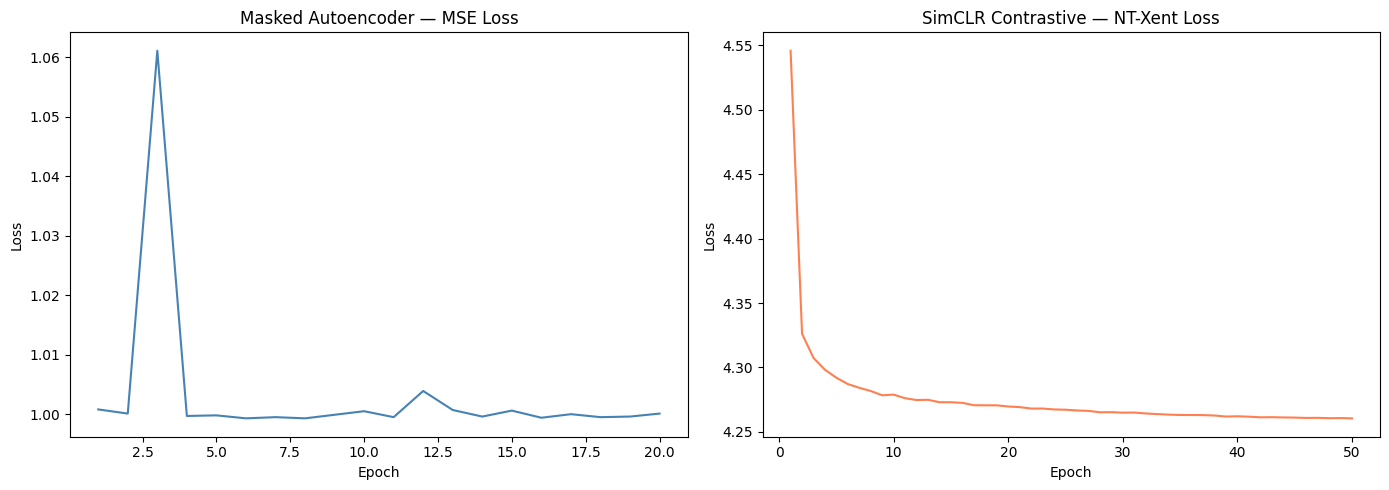

In [1]:
import matplotlib.pyplot as plt

epochs_v1 = list(range(1, 21))
losses_v1 = [1.0008, 1.0001, 1.0611, 0.9997, 0.9998, 0.9993, 0.9995,
             0.9993, 0.9999, 1.0005, 0.9995, 1.0039, 1.0007, 0.9996,
             1.0006, 0.9994, 1.0000, 0.9995, 0.9996, 1.0001]

epochs_v2 = list(range(1, 51))
losses_v2 = [4.5459, 4.3262, 4.3074, 4.2982, 4.2920, 4.2871, 4.2842,
             4.2817, 4.2784, 4.2789, 4.2761, 4.2747, 4.2749, 4.2730,
             4.2730, 4.2725, 4.2707, 4.2706, 4.2706, 4.2697, 4.2692,
             4.2681, 4.2681, 4.2674, 4.2672, 4.2666, 4.2663, 4.2652,
             4.2653, 4.2649, 4.2650, 4.2643, 4.2638, 4.2634, 4.2631,
             4.2631, 4.2630, 4.2627, 4.2619, 4.2621, 4.2618, 4.2613,
             4.2614, 4.2612, 4.2611, 4.2608, 4.2609, 4.2606, 4.2607, 4.2605]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_v1, losses_v1, color='steelblue')
axes[0].set_title("Masked Autoencoder — MSE Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epochs_v2, losses_v2, color='coral')
axes[1].set_title("SimCLR Contrastive — NT-Xent Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig('ssl_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()